In [1]:
import numpy as np

import torch
import torch.nn as nn
import pandas as pd
import os
import importlib
import sys


batch_size = 256

import torchsummary


torch.manual_seed(42)

In [2]:
# 1. Konfiguration
REPO_URL = "https://github.com/828w5tjjts-wq/Machine-Learning-Final-project.git"
PROJECT_DIR = "/kaggle/working/Machine-Learning-Final-project"

# 2. Prüfen, ob das Repo schon existiert
if os.path.exists(PROJECT_DIR):
    print("Repo existiert bereits. Ziehe neueste Änderungen (Pull)...")
    %cd {PROJECT_DIR}
    !git pull origin main
else:
    print("Repo existiert nicht. Klone von GitHub...")
    !git clone {REPO_URL} {PROJECT_DIR}
    %cd {PROJECT_DIR}

# 3. Pfad zum System-Pfad hinzufügen (damit Imports funktionieren)
sys.path.append(PROJECT_DIR)

print("Setup abgeschlossen. Projekt ist aktuell.")

Repo existiert nicht. Klone von GitHub...
Cloning into '/kaggle/working/Machine-Learning-Final-project'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 110 (delta 39), reused 77 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 37.77 KiB | 4.20 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/kaggle/working/Machine-Learning-Final-project
Setup abgeschlossen. Projekt ist aktuell.


In [3]:
from src.models.architectures import LinearRegression
from src.models.trainer import run_training
from src.data.loader import prepare_data
from src.data.loader import load_processed_data
from src.data.edit import split_data
from src.data.edit import standardize_data
from src.data.dataset import create_dataloaders
from src.models.tune import test_learning_rates
from src.models.trainer import train_model_with_early_stopping

In [4]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cuda:0


In [5]:
print("Lade listings.csv...")
df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/airbnb-listings/listings-2.csv")
X, y = prepare_data(df)
np.save('X_filtered.npy', X)
np.save('y.npy', y)

Lade listings.csv...
Gefundene Numerische Spalten: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'review_scores_rating', 'number_of_reviews', 'reviews_per_month', 'minimum_nights', 'maximum_nights', 'calculated_host_listings_count']
Gefundene Kategoriale Spalten: ['room_type', 'property_type']
Gefundene Spatial Spalten: ['latitude', 'longitude']

Final Shape X: (9229, 78)
Final Shape y: (9229,)


In [6]:
X_raw, y = load_processed_data('X_filtered.npy', 'y.npy')

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)
X_train_scaled, X_val_scaled, X_test_scaled = standardize_data(X_train, X_val, X_test)
    
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, X_val_scaled, X_test_scaled, 
    y_train, y_val, y_test, 
    batch_size=batch_size
    )
print("\nAlles bereit für das Training!")

sample_inputs, _ = next(iter(train_loader))
input_dim = sample_inputs.shape[1]

model_linear = LinearRegression(input_dim, 1)
model_linear = model_linear.to(device)

loss_function = torch.nn.MSELoss() # Mean Squared Error für Regression
optimizer = torch.optim.Adam(model_linear.parameters(), lr=0.1) 
num_epochs = 100


Daten geladen: X Shape (9229, 78), y Shape (9229,)
Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6

Alles bereit für das Training!


Starte Hyperparameter-Test für 8 Learning Rates...

--- Teste Learning Rate: 1 ---
Ergebnis LR 1: Finaler Val Loss (MSE) = 3054.4991

--- Teste Learning Rate: 0.5 ---
Ergebnis LR 0.5: Finaler Val Loss (MSE) = 2988.0952

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 4873.4316

--- Teste Learning Rate: 0.05 ---
Ergebnis LR 0.05: Finaler Val Loss (MSE) = 10354.4935

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 21522.2259

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 28243.7705

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 29348.7780

--- Teste Learning Rate: 1e-05 ---
Ergebnis LR 1e-05: Finaler Val Loss (MSE) = 29471.9290


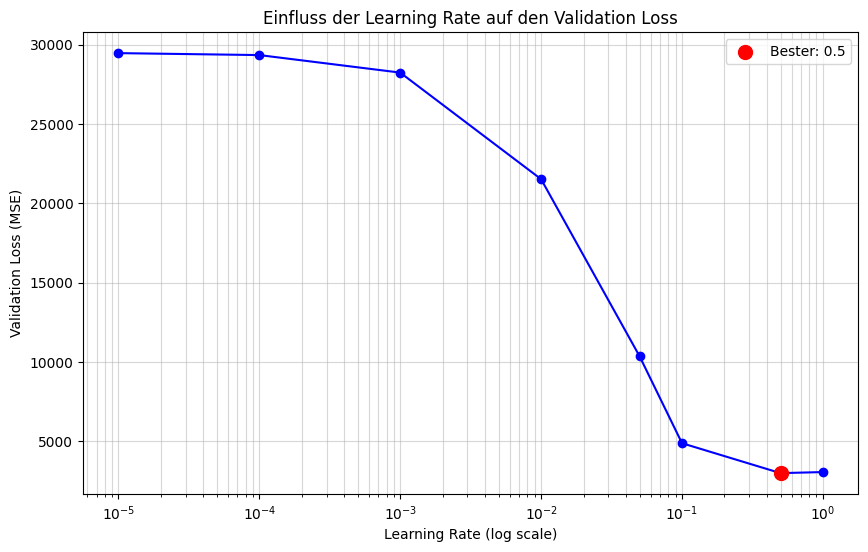


Die beste Learning Rate ist: 0.5 mit einem Loss von 2988.0952351888022


In [7]:
#Test with different Learning Rates
lrs_to_test = [1, 0.5, 0.1, 0.05, 0.01, 0.001, 0.0001, 0.00001]

best_lr, best_loss = test_learning_rates(
    learning_rates=lrs_to_test,
    model_class=LinearRegression,
    input_dim=input_dim,    
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50 
)

print(f"\nDie beste Learning Rate ist: {best_lr} mit einem Loss von {best_loss}")

Starte Hyperparameter-Test für 10 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 8724.5626

--- Teste Learning Rate: 0.2 ---
Ergebnis LR 0.2: Finaler Val Loss (MSE) = 4039.4998

--- Teste Learning Rate: 0.3 ---
Ergebnis LR 0.3: Finaler Val Loss (MSE) = 3170.8017

--- Teste Learning Rate: 0.4 ---
Ergebnis LR 0.4: Finaler Val Loss (MSE) = 2992.5057

--- Teste Learning Rate: 0.5 ---
Ergebnis LR 0.5: Finaler Val Loss (MSE) = 2986.7769

--- Teste Learning Rate: 0.6 ---
Ergebnis LR 0.6: Finaler Val Loss (MSE) = 3011.4880

--- Teste Learning Rate: 0.7 ---
Ergebnis LR 0.7: Finaler Val Loss (MSE) = 2935.4581

--- Teste Learning Rate: 0.8 ---
Ergebnis LR 0.8: Finaler Val Loss (MSE) = 3041.0507

--- Teste Learning Rate: 0.9 ---
Ergebnis LR 0.9: Finaler Val Loss (MSE) = 3032.9643

--- Teste Learning Rate: 1.0 ---
Ergebnis LR 1.0: Finaler Val Loss (MSE) = 3037.9497


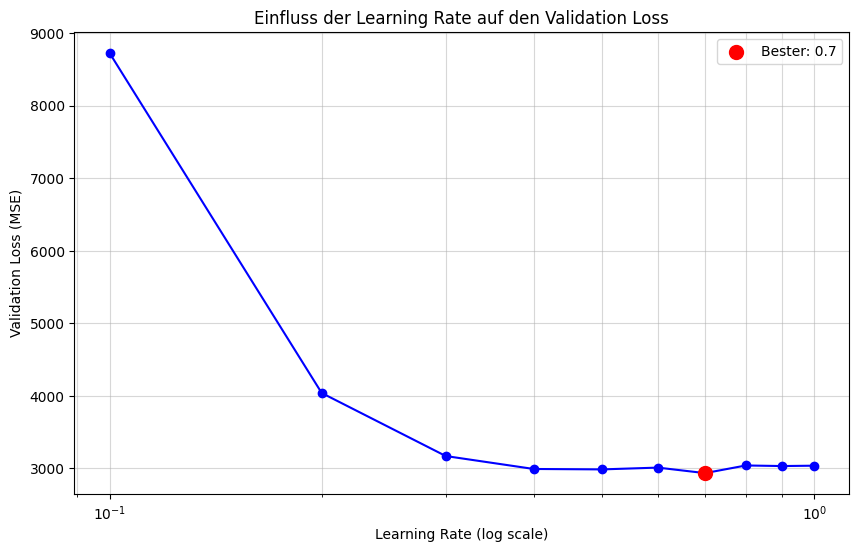


Die beste Learning Rate ist: 0.7 mit einem Loss von 2935.4581298828125


In [8]:
#Da anscheinend die beste Learning-Rate im Breich 1 bis 0.1 liegt nochmal
#genauere Analyse dieses Bereichs 

lrs_to_test_2 = [i / 10 for i in range(1, 11)]
best_lr, best_loss = test_learning_rates(
    learning_rates=lrs_to_test_2,
    model_class=LinearRegression,
    input_dim=input_dim,    
    output_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=30 
)

print(f"\nDie beste Learning Rate ist: {best_lr} mit einem Loss von {best_loss}")

In [9]:
# Teste beste Learning Rate für beste num_epochs
model_linear = LinearRegression(input_dim, 1)
model_linear = model_linear.to(device)

loss_function = torch.nn.MSELoss() # Mean Squared Error für Regression
optimizer = torch.optim.Adam(model_linear.parameters(), lr=best_lr) 

history = train_model_with_early_stopping(
    model=model_linear,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=200,
    device=device,
    )

Starte Training mit Early Stopping (Patience=5)...
Epoch 1/200 | Train Loss: 26269.3625 | Train RMSE: 159.54€ | Val Loss: 19485.9251 | Val RMSE: 140.00€
Epoch 2/200 | Train Loss: 17567.1637 | Train RMSE: 133.11€ | Val Loss: 14993.3919 | Val RMSE: 122.84€
Epoch 3/200 | Train Loss: 12913.0682 | Train RMSE: 114.39€ | Val Loss: 11771.9925 | Val RMSE: 109.03€
Epoch 4/200 | Train Loss: 9820.6408 | Train RMSE: 99.42€ | Val Loss: 9243.5999 | Val RMSE: 96.76€
Epoch 5/200 | Train Loss: 8272.9595 | Train RMSE: 86.83€ | Val Loss: 7404.7995 | Val RMSE: 86.76€
Epoch 6/200 | Train Loss: 6193.1104 | Train RMSE: 76.90€ | Val Loss: 5926.8388 | Val RMSE: 77.76€
Epoch 7/200 | Train Loss: 4717.2731 | Train RMSE: 69.38€ | Val Loss: 5101.9291 | Val RMSE: 72.38€
Epoch 8/200 | Train Loss: 4060.4068 | Train RMSE: 63.97€ | Val Loss: 4371.0558 | Val RMSE: 67.15€
Epoch 9/200 | Train Loss: 3548.5622 | Train RMSE: 60.21€ | Val Loss: 3927.2996 | Val RMSE: 63.70€
Epoch 10/200 | Train Loss: 3599.6032 | Train RMSE: 57.8

In [10]:
# 1. Änderungen von GitHub herunterladen und mergen
#!git pull origin main --allow-unrelated-histories